# 🔧 Feature Engineering va Scaling

**Maqsad:** Raw data'ni ML modellar uchun optimal features'ga aylantirish san'atini o'rganish

**Mavzular:**
- ✅ Feature Selection (Filter, Wrapper, Embedded)
- ✅ Feature Scaling (Normalization, Standardization, Robust)
- ✅ Feature Creation (Polynomial, Interactions, Datetime)
- ✅ Feature Encoding (Label, One-Hot, Target)
- ✅ Complete Pipeline Building

---

> *"Applied machine learning is basically feature engineering."* - Andrew Ng

## 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest, chi2, f_classif, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)

# Feature Scaling
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    Normalizer, PowerTransformer
)

# Feature Encoding
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)

# Feature Creation
from sklearn.preprocessing import PolynomialFeatures

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---

## 1️⃣ Feature Selection - Xususiyatlar Tanlash

**Maqsad:** Eng muhim va foydali features'ni tanlash, keraksizlarini olib tashlash

**Nima uchun kerak?**
- 🎯 Model performance'ni yaxshilash
- ⚡ Training time'ni kamaytirish
- 📉 Overfitting'ni kamaytirish
- 💡 Model interpretability'ni oshirish

**3 ta asosiy usul:**
1. **Filter Methods** - Statistik testlar
2. **Wrapper Methods** - Model performance
3. **Embedded Methods** - Model training paytida

### 1.1 Dataset Preparation

In [2]:
# Load Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("="*70)
print("DATASET INFO")
print("="*70)
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target: {np.unique(y)} (0=Malignant, 1=Benign)")
print(f"Feature names: {list(X.columns[:5])}... (showing first 5)")
print("="*70)

# Feature statistics
print("\nFEATURE STATISTICS:")
print(X.describe().iloc[:, :5])  # First 5 features

X.head()

DATASET INFO
Features: 30
Samples: 569
Target: [0 1] (0=Malignant, 1=Benign)
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']... (showing first 5)

FEATURE STATISTICS:
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 1.2 Filter Methods - Statistik Testlar

**Filter Methods:** Model train qilmasdan, statistik testlar orqali features tanlash

**Keng tarqalgan metodlar:**
- **Variance Threshold:** Past variance'li features'ni o'chirish
- **Chi-Square Test:** Categorical features uchun
- **F-test (ANOVA):** Numerical features uchun
- **Mutual Information:** Non-linear dependencies

**Advantages:** ⚡ Tez, 🔄 Model-independent  
**Disadvantages:** ❌ Feature interactions e'tiborsiz

1. VARIANCE THRESHOLD
Original features: 30
After variance threshold: 11
Removed: 19 features
Removed features: ['mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry']...

2. SELECT K BEST (F-TEST)
Selected top 10 features:
             Feature    F-Score
worst concave points 964.385393
     worst perimeter 897.944219
 mean concave points 861.676020
        worst radius 860.781707
      mean perimeter 697.235272
          worst area 661.600206
         mean radius 646.981021
           mean area 573.060747
      mean concavity 533.793126
     worst concavity 436.691939


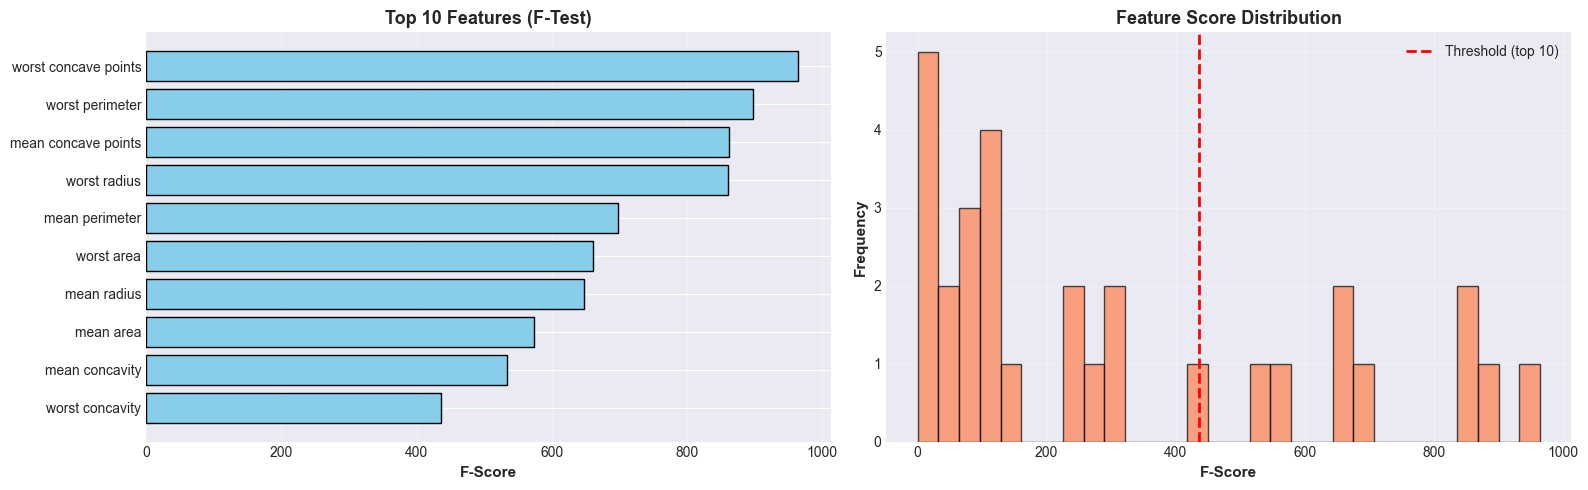


✅ Filter methods applied successfully!


In [3]:
# Method 1: Variance Threshold
print("="*70)
print("1. VARIANCE THRESHOLD")
print("="*70)

# Remove low variance features
variance_selector = VarianceThreshold(threshold=0.1)
X_var = variance_selector.fit_transform(X)

removed_features = X.columns[~variance_selector.get_support()].tolist()
kept_features = X.columns[variance_selector.get_support()].tolist()

print(f"Original features: {X.shape[1]}")
print(f"After variance threshold: {X_var.shape[1]}")
print(f"Removed: {len(removed_features)} features")
if removed_features:
    print(f"Removed features: {removed_features[:5]}...")  # Show first 5

# Method 2: SelectKBest with F-test
print("\n" + "="*70)
print("2. SELECT K BEST (F-TEST)")
print("="*70)

k = 10  # Select top 10 features
selector_f = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector_f.fit_transform(X, y)

# Get selected features
selected_indices = selector_f.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()
scores = selector_f.scores_

print(f"Selected top {k} features:")
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': scores
}).sort_values('F-Score', ascending=False).head(k)
print(feature_scores.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 features by F-score
ax1 = axes[0]
top_features = feature_scores.head(10)
ax1.barh(range(len(top_features)), top_features['F-Score'], color='skyblue', edgecolor='black')
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels([f[:20] for f in top_features['Feature']])  # Truncate long names
ax1.set_xlabel('F-Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Features (F-Test)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Feature score distribution
ax2 = axes[1]
ax2.hist(scores, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(scores[selected_indices].min(), color='red', linestyle='--', 
            lw=2, label=f'Threshold (top {k})')
ax2.set_xlabel('F-Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Feature Score Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Filter methods applied successfully!")

### 1.3 Wrapper Methods - RFE (Recursive Feature Elimination)

**Wrapper Methods:** Model performance orqali features tanlash

**RFE Algorithm:**
1. Barcha features bilan model train qilish
2. Eng kam muhim feature'ni o'chirish
3. Qaytadan train qilish
4. Kerakli sondagi features qolguncha takrorlash

**Advantages:** ✅ Model-specific, ✅ Feature interactions  
**Disadvantages:** ⏰ Sekin, ⚠️ Overfitting xavfi

RECURSIVE FEATURE ELIMINATION (RFE)
Selected 10 features:
             Feature  Selected  Ranking
         mean radius      True        1
      worst symmetry      True        1
       texture error      True        1
    worst smoothness      True        1
   worst compactness      True        1
      mean concavity      True        1
        worst radius      True        1
     worst concavity      True        1
worst concave points      True        1
    mean compactness      True        1
 mean concave points     False        2
     perimeter error     False        3
       mean symmetry     False        4
       worst texture     False        5
     mean smoothness     False        6


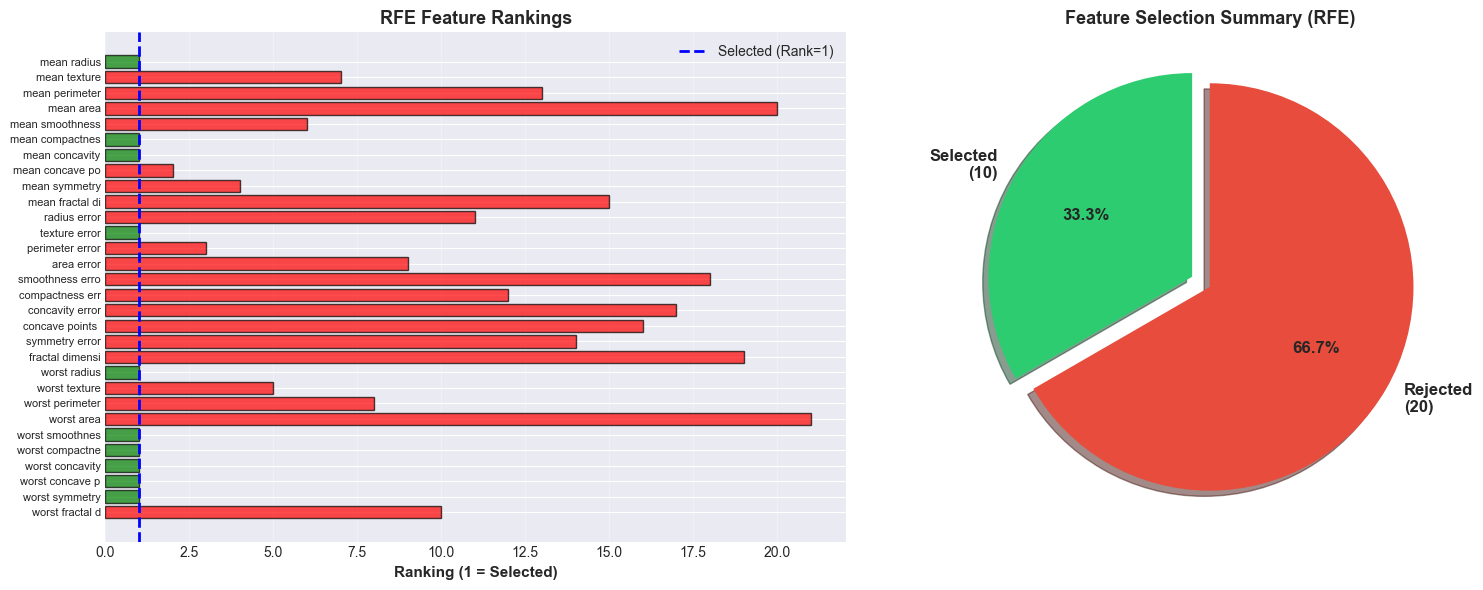


✅ RFE completed!


In [4]:
# RFE with Logistic Regression
print("="*70)
print("RECURSIVE FEATURE ELIMINATION (RFE)")
print("="*70)

# Create model
model = LogisticRegression(max_iter=10000, random_state=42)

# RFE: Select top 10 features
n_features_to_select = 10
rfe = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
X_rfe = rfe.fit_transform(X, y)

# Selected features
rfe_selected = X.columns[rfe.support_].tolist()
rfe_ranking = rfe.ranking_

print(f"Selected {n_features_to_select} features:")
rfe_df = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe_ranking
}).sort_values('Ranking')
print(rfe_df.head(15).to_string(index=False))

# Visualization: Feature Rankings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: RFE Rankings
ax1 = axes[0]
colors = ['green' if s else 'red' for s in rfe.support_]
ax1.barh(range(len(X.columns)), rfe_ranking, color=colors, edgecolor='black', alpha=0.7)
ax1.axvline(x=1, color='blue', linestyle='--', lw=2, label='Selected (Rank=1)')
ax1.set_yticks(range(len(X.columns)))
ax1.set_yticklabels([f[:15] for f in X.columns], fontsize=8)
ax1.set_xlabel('Ranking (1 = Selected)', fontsize=11, fontweight='bold')
ax1.set_title('RFE Feature Rankings', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Plot 2: Selected vs Rejected
ax2 = axes[1]
selected_count = np.sum(rfe.support_)
rejected_count = len(X.columns) - selected_count
sizes = [selected_count, rejected_count]
labels = [f'Selected\n({selected_count})', f'Rejected\n({rejected_count})']
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.1, 0)
ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Feature Selection Summary (RFE)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ RFE completed!")

### 1.4 Embedded Methods - Feature Importance

**Embedded Methods:** Model training paytida feature selection

**Tree-based Feature Importance:**
- Random Forest, XGBoost, LightGBM
- Gini/Entropy importance
- Gain-based importance

**Advantages:** ⚡ Fast, 🎯 Model-specific  
**Disadvantages:** 📉 Model-dependent

FEATURE IMPORTANCE (RANDOM FOREST)
Top 10 Most Important Features:
             Feature  Importance
          worst area    0.139544
worst concave points    0.132698
 mean concave points    0.106717
        worst radius    0.082618
     worst perimeter    0.081110
      mean perimeter    0.068161
      mean concavity    0.066943
           mean area    0.060033
     worst concavity    0.037172
         mean radius    0.034893

✅ Selected 15 features (threshold=median)
   Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']...


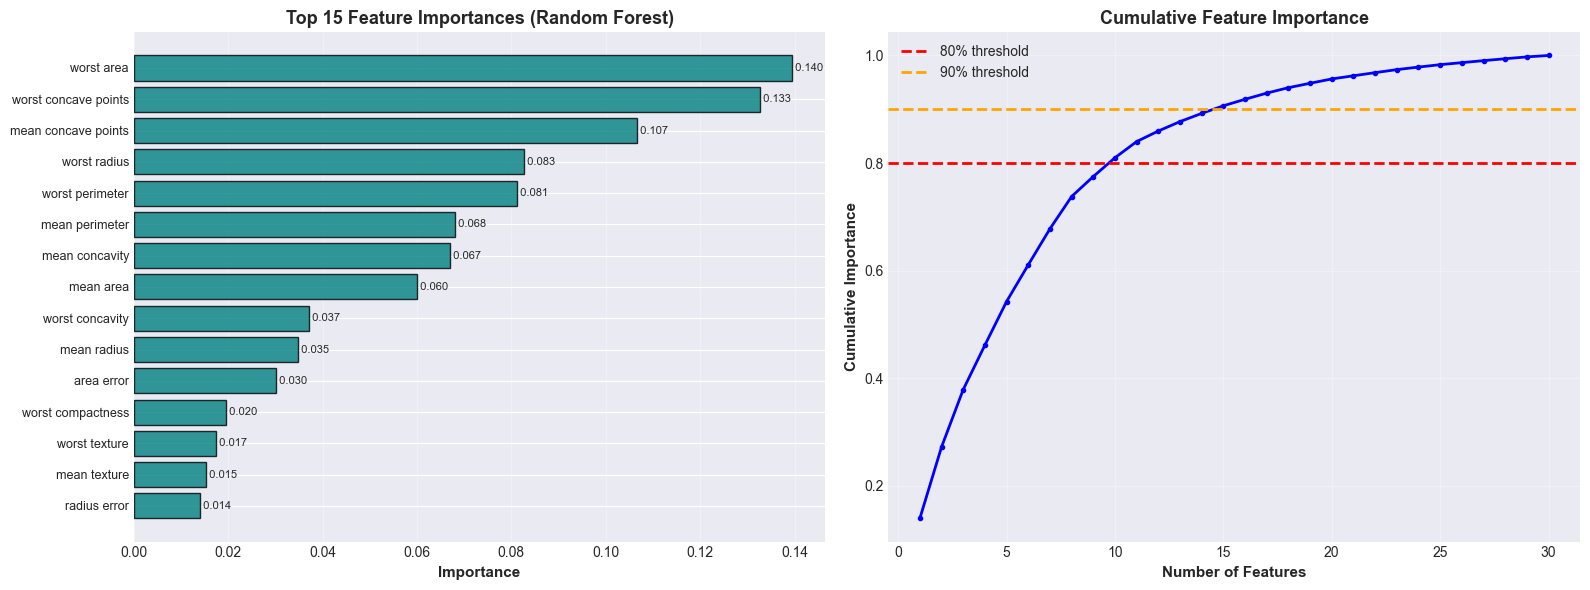


📊 Cumulative Importance Analysis:
   10 features cover 80% importance
   15 features cover 90% importance


In [5]:
# Random Forest Feature Importance
print("="*70)
print("FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*70)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X, y)

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))

# SelectFromModel: Automatic threshold
selector_importance = SelectFromModel(rf_model, threshold='median', prefit=True)
X_important = selector_importance.transform(X)
selected_features_importance = X.columns[selector_importance.get_support()].tolist()

print(f"\n✅ Selected {len(selected_features_importance)} features (threshold=median)")
print(f"   Features: {selected_features_importance[:5]}...")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 15 Feature Importances
ax1 = axes[0]
top_15 = feature_importance_df.head(15)
bars = ax1.barh(range(len(top_15)), top_15['Importance'], 
                color='teal', edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels([f[:20] for f in top_15['Feature']], fontsize=9)
ax1.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_15['Importance'])):
    ax1.text(val, i, f' {val:.3f}', va='center', fontsize=8)

# Plot 2: Cumulative Importance
ax2 = axes[1]
sorted_importances = np.sort(importances)[::-1]
cumulative_importances = np.cumsum(sorted_importances)
ax2.plot(range(1, len(cumulative_importances) + 1), cumulative_importances, 
         'b-', lw=2, marker='o', markersize=3)
ax2.axhline(y=0.8, color='red', linestyle='--', lw=2, label='80% threshold')
ax2.axhline(y=0.9, color='orange', linestyle='--', lw=2, label='90% threshold')
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find features for 80% and 90% importance
n_features_80 = np.argmax(cumulative_importances >= 0.8) + 1
n_features_90 = np.argmax(cumulative_importances >= 0.9) + 1
print(f"\n📊 Cumulative Importance Analysis:")
print(f"   {n_features_80} features cover 80% importance")
print(f"   {n_features_90} features cover 90% importance")
print("="*70)

---

## 2️⃣ Feature Scaling - Masshtablash

**Maqsad:** Features'ni bir xil range'ga keltirish

**Nima uchun kerak?**
- 🎯 Distance-based algorithms (KNN, SVM, K-Means)
- 🧮 Gradient Descent optimization (Linear Regression, Neural Networks)
- 🔄 Equal feature importance

**Scaling Methods:**
1. **StandardScaler** (Z-score normalization): μ=0, σ=1
2. **MinMaxScaler** (Normalization): [0, 1]
3. **RobustScaler**: Outliers'ga robust
4. **MaxAbsScaler**: [-1, 1]

**❗ Important:** Tree-based models (Decision Trees, Random Forest, XGBoost) scaling'ga muhtoj emas!

### 2.1 Scaling Methods Comparison

ORIGINAL DATA STATISTICS
              Age         Income       Score
count  100.000000     100.000000  100.000000
mean    43.350000   96041.270000   51.377368
std     14.904663   49508.490183   28.541641
min     19.000000   20206.000000    0.052038
25%     31.750000   62111.250000   26.875450
50%     42.000000   93680.000000   48.975373
75%     57.000000  129838.750000   74.774725
max     69.000000  300000.000000   99.774049


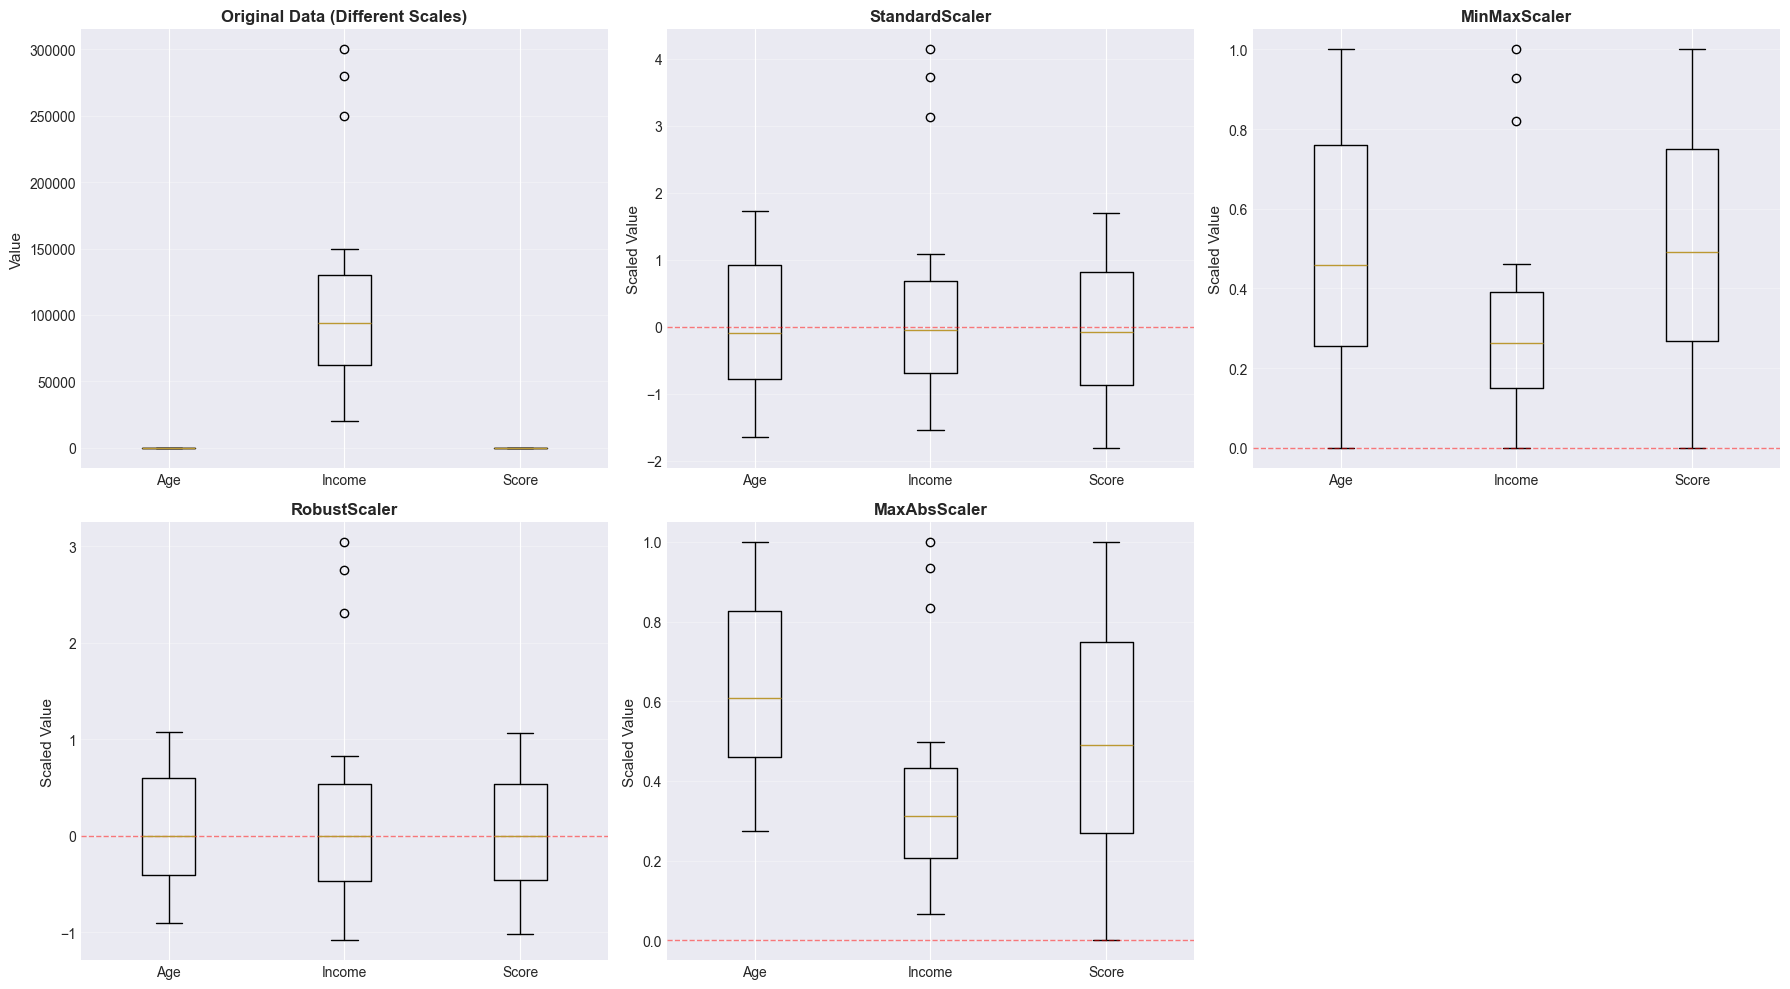


SCALED DATA RANGES

StandardScaler:
  Age:    [-1.64, 1.73]
  Income: [-1.54, 4.14]
  Score:  [-1.81, 1.70]

MinMaxScaler:
  Age:    [0.00, 1.00]
  Income: [0.00, 1.00]
  Score:  [0.00, 1.00]

RobustScaler:
  Age:    [-0.91, 1.07]
  Income: [-1.08, 3.05]
  Score:  [-1.02, 1.06]

MaxAbsScaler:
  Age:    [0.28, 1.00]
  Income: [0.07, 1.00]
  Score:  [0.00, 1.00]


In [6]:
# Sample data with different scales
np.random.seed(42)
data_original = pd.DataFrame({
    'Age': np.random.randint(18, 70, 100),
    'Income': np.random.randint(20000, 150000, 100),
    'Score': np.random.uniform(0, 100, 100)
})

# Add some outliers
data_original.loc[95:97, 'Income'] = [250000, 300000, 280000]

print("="*70)
print("ORIGINAL DATA STATISTICS")
print("="*70)
print(data_original.describe())

# Apply different scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = pd.DataFrame(
        scaler.fit_transform(data_original),
        columns=data_original.columns
    )

# Visualization: Compare scalers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Original data
ax = axes[0]
ax.boxplot([data_original['Age'], data_original['Income'], data_original['Score']], 
           labels=['Age', 'Income', 'Score'])
ax.set_title('Original Data (Different Scales)', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Scaled data
for i, (name, data_scaled) in enumerate(scaled_data.items(), 1):
    ax = axes[i]
    ax.boxplot([data_scaled['Age'], data_scaled['Income'], data_scaled['Score']], 
               labels=['Age', 'Income', 'Score'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Scaled Value', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='red', linestyle='--', lw=1, alpha=0.5)

# Hide last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Print scaled ranges
print("\n" + "="*70)
print("SCALED DATA RANGES")
print("="*70)
for name, data_scaled in scaled_data.items():
    print(f"\n{name}:")
    print(f"  Age:    [{data_scaled['Age'].min():.2f}, {data_scaled['Age'].max():.2f}]")
    print(f"  Income: [{data_scaled['Income'].min():.2f}, {data_scaled['Income'].max():.2f}]")
    print(f"  Score:  [{data_scaled['Score'].min():.2f}, {data_scaled['Score'].max():.2f}]")
print("="*70)

### 2.2 Scaling Impact on Model Performance

Scaling'ning turli algoritmlarga ta'sirini ko'ramiz!

SCALING IMPACT ON MODEL PERFORMANCE
Logistic Regression  + No Scaling     : Accuracy = 0.9561
Logistic Regression  + StandardScaler : Accuracy = 0.9737
Logistic Regression  + MinMaxScaler   : Accuracy = 0.9825
Logistic Regression  + RobustScaler   : Accuracy = 0.9825
KNN                  + No Scaling     : Accuracy = 0.9561
KNN                  + StandardScaler : Accuracy = 0.9474
KNN                  + MinMaxScaler   : Accuracy = 0.9649
KNN                  + RobustScaler   : Accuracy = 0.9561
SVM                  + No Scaling     : Accuracy = 0.9474
SVM                  + StandardScaler : Accuracy = 0.9825
SVM                  + MinMaxScaler   : Accuracy = 0.9737
SVM                  + RobustScaler   : Accuracy = 0.9649
Decision Tree        + No Scaling     : Accuracy = 0.9474
Decision Tree        + StandardScaler : Accuracy = 0.9474
Decision Tree        + MinMaxScaler   : Accuracy = 0.9474
Decision Tree        + RobustScaler   : Accuracy = 0.9474


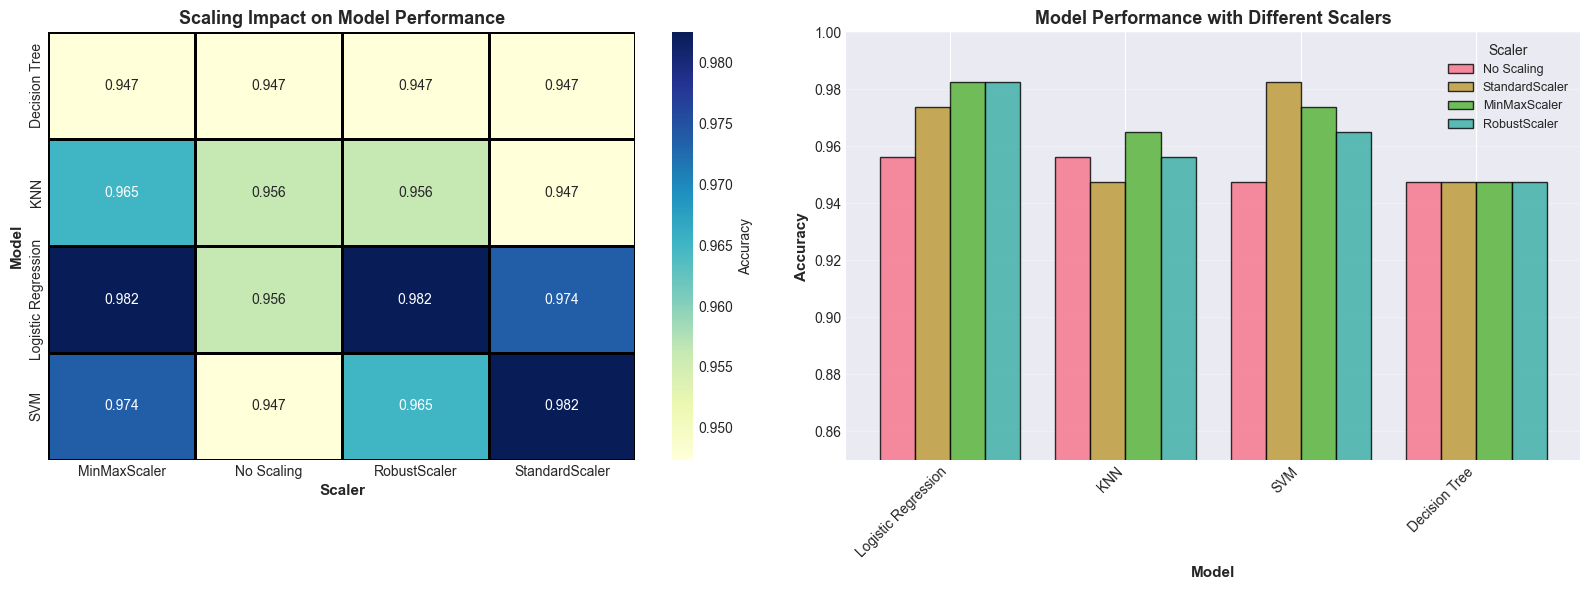


KEY INSIGHTS:
✅ KNN, SVM: Scaling CRITICAL! (distance-based)
✅ Logistic Regression: Scaling helps! (gradient descent)
✅ Decision Tree: Scaling NOT needed! (split-based)


In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

# Scalers to test
scalers_test = {
    'No Scaling': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Results storage
results = []

print("="*70)
print("SCALING IMPACT ON MODEL PERFORMANCE")
print("="*70)

for model_name, model in models.items():
    for scaler_name, scaler in scalers_test.items():
        # Apply scaling
        if scaler is None:
            X_train_scaled = X_train
            X_test_scaled = X_test
        else:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        
        # Train and evaluate
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            'Model': model_name,
            'Scaler': scaler_name,
            'Accuracy': acc
        })
        
        print(f"{model_name:20s} + {scaler_name:15s}: Accuracy = {acc:.4f}")

# Results DataFrame
df_results = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Heatmap
ax1 = axes[0]
pivot_table = df_results.pivot(index='Model', columns='Scaler', values='Accuracy')
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Accuracy'}, ax=ax1, linewidths=1, linecolor='black')
ax1.set_title('Scaling Impact on Model Performance', fontsize=13, fontweight='bold')
ax1.set_xlabel('Scaler', fontsize=11, fontweight='bold')
ax1.set_ylabel('Model', fontsize=11, fontweight='bold')

# Plot 2: Grouped bar chart
ax2 = axes[1]
x = np.arange(len(models))
width = 0.2
scalers_list = list(scalers_test.keys())

for i, scaler in enumerate(scalers_list):
    scaler_results = df_results[df_results['Scaler'] == scaler]
    accuracies = [scaler_results[scaler_results['Model'] == m]['Accuracy'].values[0] 
                  for m in models.keys()]
    ax2.bar(x + i*width, accuracies, width, label=scaler, alpha=0.8, edgecolor='black')

ax2.set_xlabel('Model', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Model Performance with Different Scalers', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(models.keys(), rotation=45, ha='right')
ax2.legend(title='Scaler', fontsize=9, title_fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
print("✅ KNN, SVM: Scaling CRITICAL! (distance-based)")
print("✅ Logistic Regression: Scaling helps! (gradient descent)")
print("✅ Decision Tree: Scaling NOT needed! (split-based)")
print("="*70)

---

## 3️⃣ Feature Creation - Yangi Features Yaratish

**Maqsad:** Mavjud features'dan yangi, informative features yaratish

**Methods:**
1. **Polynomial Features** - Higher-order interactions
2. **Manual Interactions** - Domain knowledge
3. **Date/Time Features** - Temporal patterns
4. **Aggregations** - Statistical features

**Key:** Domain knowledge + creativity!

### 3.1 Polynomial Features

POLYNOMIAL FEATURES
Original features: 1
After polynomial (degree=2): 3
Feature names: ['1' 'x' 'x^2']

Linear Regression R²: 0.4297
Polynomial Regression R²: 0.8569
Improvement: 0.4272 (99.4%)


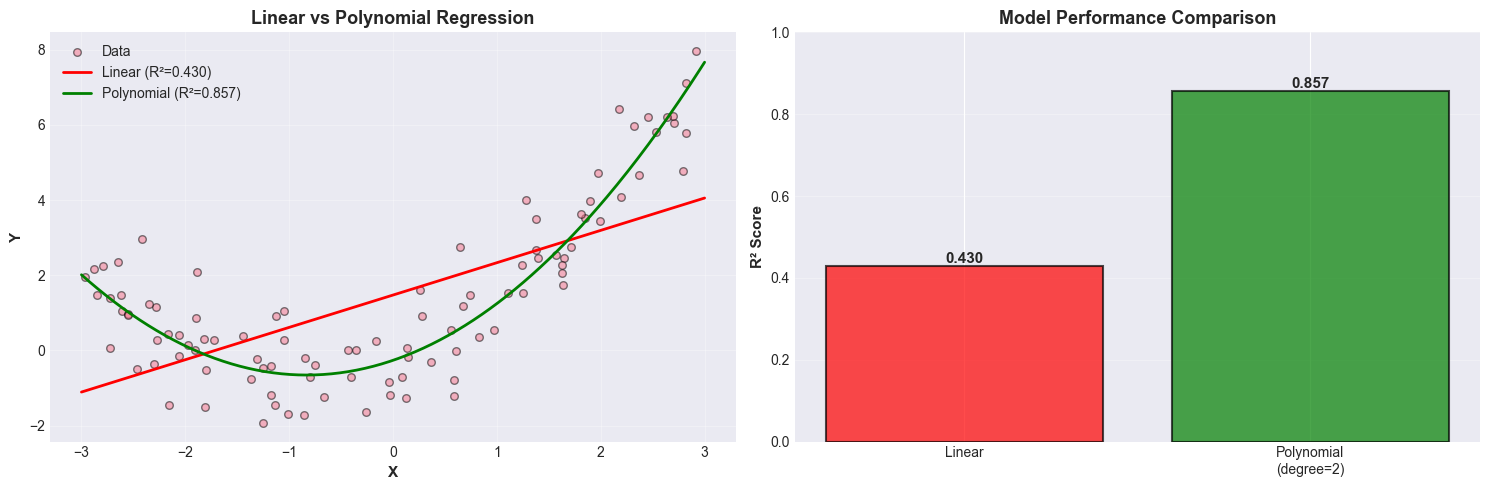


✅ Polynomial features can capture non-linear relationships!


In [8]:
# Generate sample data with non-linear relationship
np.random.seed(42)
X_simple = np.random.uniform(-3, 3, 100).reshape(-1, 1)
y_simple = 0.5 * X_simple**2 + X_simple + np.random.normal(0, 1, (100, 1))

# Original features
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train_simple)
X_test_poly = poly.transform(X_test_simple)

print("="*70)
print("POLYNOMIAL FEATURES")
print("="*70)
print(f"Original features: {X_simple.shape[1]}")
print(f"After polynomial (degree=2): {X_train_poly.shape[1]}")
print(f"Feature names: {poly.get_feature_names_out(['x'])}")
print("="*70)

# Train models
model_linear = LinearRegression()
model_poly = LinearRegression()

model_linear.fit(X_train_simple, y_train_simple)
model_poly.fit(X_train_poly, y_train_simple)

# Predictions
y_pred_linear = model_linear.predict(X_test_simple)
y_pred_poly = model_poly.predict(X_test_poly)

# Scores
r2_linear = r2_score(y_test_simple, y_pred_linear)
r2_poly = r2_score(y_test_simple, y_pred_poly)

print(f"\nLinear Regression R²: {r2_linear:.4f}")
print(f"Polynomial Regression R²: {r2_poly:.4f}")
print(f"Improvement: {r2_poly - r2_linear:.4f} ({(r2_poly - r2_linear)/r2_linear*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Linear vs Polynomial Fit
ax1 = axes[0]
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot_linear = model_linear.predict(X_plot)
y_plot_poly = model_poly.predict(X_plot_poly)

ax1.scatter(X_simple, y_simple, alpha=0.5, s=30, label='Data', edgecolor='black')
ax1.plot(X_plot, y_plot_linear, 'r-', lw=2, label=f'Linear (R²={r2_linear:.3f})')
ax1.plot(X_plot, y_plot_poly, 'g-', lw=2, label=f'Polynomial (R²={r2_poly:.3f})')
ax1.set_xlabel('X', fontsize=11, fontweight='bold')
ax1.set_ylabel('Y', fontsize=11, fontweight='bold')
ax1.set_title('Linear vs Polynomial Regression', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: R² Comparison
ax2 = axes[1]
models_names = ['Linear', 'Polynomial\n(degree=2)']
r2_scores = [r2_linear, r2_poly]
colors = ['red', 'green']
bars = ax2.bar(models_names, r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, r2_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Polynomial features can capture non-linear relationships!")

### 3.2 Manual Feature Engineering Examples

MANUAL FEATURE ENGINEERING EXAMPLES

Original Features:
   Age  Height_cm  Weight_kg  Income  Years_Experience  Purchase_Count  \
0   58        198         57  112637                26              44   
1   48        151         95   81934                17              19   
2   34        151         65   94895                11              42   
3   62        177         63   62307                 0              41   
4   27        172         61   84098                21              37   

   Total_Spent       Date  
0  1897.817396 2023-01-01  
1  9093.660557 2023-01-02  
2  5875.578768 2023-01-03  
3  4068.429026 2023-01-04  
4  4673.857456 2023-01-05  

ENGINEERED FEATURES:

1. BMI (Body Mass Index):
   Formula: Weight / (Height² in meters)
   Sample: [14.539332721150904, 41.6648392614359, 28.507521599929827, 20.109164033323754, 20.61925365062196]

2. Average Purchase Amount:
   Formula: Total_Spent / Purchase_Count
   Sample: [43.13221355304805, 478.6137135369958, 139.89473257

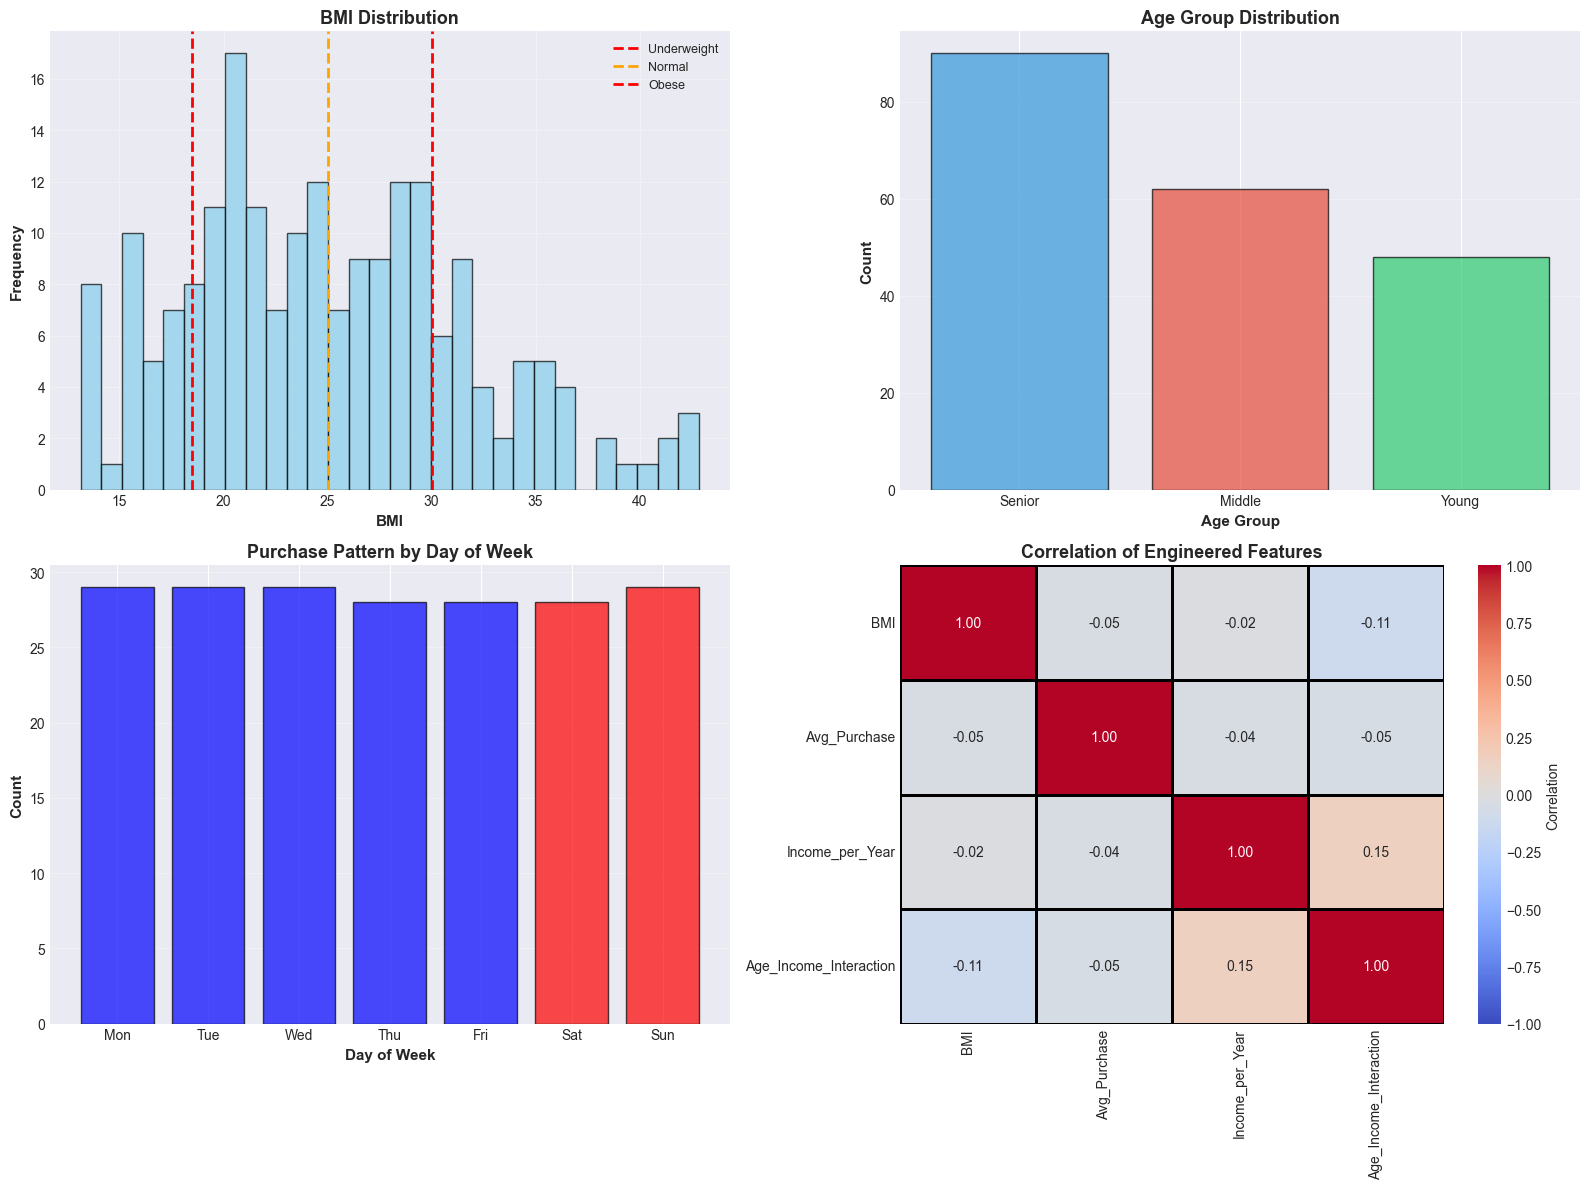


✅ Feature engineering complete!


In [9]:
# Create sample dataset with real-world features
np.random.seed(42)
n_samples = 200

data_fe = pd.DataFrame({
    'Age': np.random.randint(20, 65, n_samples),
    'Height_cm': np.random.randint(150, 200, n_samples),
    'Weight_kg': np.random.randint(50, 100, n_samples),
    'Income': np.random.randint(30000, 120000, n_samples),
    'Years_Experience': np.random.randint(0, 30, n_samples),
    'Purchase_Count': np.random.randint(1, 50, n_samples),
    'Total_Spent': np.random.uniform(100, 10000, n_samples),
    'Date': pd.date_range('2023-01-01', periods=n_samples, freq='D')
})

print("="*70)
print("MANUAL FEATURE ENGINEERING EXAMPLES")
print("="*70)
print("\nOriginal Features:")
print(data_fe.head())

# 1. BMI Calculation
data_fe['BMI'] = data_fe['Weight_kg'] / ((data_fe['Height_cm'] / 100) ** 2)

# 2. Average Purchase Amount
data_fe['Avg_Purchase'] = data_fe['Total_Spent'] / data_fe['Purchase_Count']

# 3. Income per Year Experience
data_fe['Income_per_Year'] = data_fe['Income'] / (data_fe['Years_Experience'] + 1)

# 4. Age Group (binning)
data_fe['Age_Group'] = pd.cut(data_fe['Age'], bins=[0, 30, 45, 100], 
                               labels=['Young', 'Middle', 'Senior'])

# 5. Date/Time Features
data_fe['Year'] = data_fe['Date'].dt.year
data_fe['Month'] = data_fe['Date'].dt.month
data_fe['DayOfWeek'] = data_fe['Date'].dt.dayofweek
data_fe['Quarter'] = data_fe['Date'].dt.quarter
data_fe['IsWeekend'] = (data_fe['DayOfWeek'] >= 5).astype(int)

# 6. Interaction Features
data_fe['Age_Income_Interaction'] = data_fe['Age'] * data_fe['Income']

print("\n" + "="*70)
print("ENGINEERED FEATURES:")
print("="*70)
print("\n1. BMI (Body Mass Index):")
print(f"   Formula: Weight / (Height² in meters)")
print(f"   Sample: {data_fe['BMI'].head().tolist()}")

print("\n2. Average Purchase Amount:")
print(f"   Formula: Total_Spent / Purchase_Count")
print(f"   Sample: {data_fe['Avg_Purchase'].head().tolist()}")

print("\n3. Income per Year Experience:")
print(f"   Formula: Income / (Years_Experience + 1)")
print(f"   Sample: {data_fe['Income_per_Year'].head().tolist()}")

print("\n4. Age Group (Binning):")
print(f"   Categories: {data_fe['Age_Group'].unique()}")
print(f"   Distribution: {data_fe['Age_Group'].value_counts().to_dict()}")

print("\n5. Date/Time Features:")
print(f"   Year, Month, DayOfWeek, Quarter, IsWeekend")
print(f"   Sample: Year={data_fe['Year'].iloc[0]}, Month={data_fe['Month'].iloc[0]}, "
      f"DayOfWeek={data_fe['DayOfWeek'].iloc[0]}, IsWeekend={data_fe['IsWeekend'].iloc[0]}")

print("\n6. Interaction Feature:")
print(f"   Age × Income")
print(f"   Sample: {data_fe['Age_Income_Interaction'].head().tolist()}")

print("\n" + "="*70)
print(f"Original features: 8")
print(f"After engineering: {data_fe.shape[1]}")
print(f"New features added: {data_fe.shape[1] - 8}")
print("="*70)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: BMI Distribution
ax1 = axes[0, 0]
ax1.hist(data_fe['BMI'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(18.5, color='red', linestyle='--', lw=2, label='Underweight')
ax1.axvline(25, color='orange', linestyle='--', lw=2, label='Normal')
ax1.axvline(30, color='red', linestyle='--', lw=2, label='Obese')
ax1.set_xlabel('BMI', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('BMI Distribution', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Age Group Distribution
ax2 = axes[0, 1]
age_group_counts = data_fe['Age_Group'].value_counts()
ax2.bar(age_group_counts.index.astype(str), age_group_counts.values, 
        color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.7)
ax2.set_xlabel('Age Group', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Age Group Distribution', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Day of Week Purchase Pattern
ax3 = axes[1, 0]
dow_counts = data_fe['DayOfWeek'].value_counts().sort_index()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors_dow = ['blue' if i < 5 else 'red' for i in range(7)]
ax3.bar(dow_labels, [dow_counts.get(i, 0) for i in range(7)], 
        color=colors_dow, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Day of Week', fontsize=11, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('Purchase Pattern by Day of Week', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Correlation of Engineered Features
ax4 = axes[1, 1]
corr_features = ['BMI', 'Avg_Purchase', 'Income_per_Year', 'Age_Income_Interaction']
corr_matrix = data_fe[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={'label': 'Correlation'}, ax=ax4, linewidths=1, linecolor='black',
            vmin=-1, vmax=1, center=0)
ax4.set_title('Correlation of Engineered Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Feature engineering complete!")

---

## 4️⃣ Feature Encoding - Kategorik → Numerical

**Maqsad:** Kategorik ma'lumotlarni raqamli formatga o'tkazish

**Encoding Methods:**
1. **Label Encoding** - Ordinal categories (tartibli)
2. **One-Hot Encoding** - Nominal categories (tartibs raqamsiz)
3. **Target Encoding** - Mean target per category
4. **Frequency Encoding** - Count per category

**Qachon qaysi usulni ishlatish kerak?**

### 4.1 Encoding Methods Comparison

CATEGORICAL DATA SAMPLE
     Education     City  Color  Salary
0       Master       LA    Red   32200
1          PhD       LA   Blue  142476
2  High School  Chicago  Green   98497
3       Master       LA   Blue   76975
4       Master       LA   Blue   51357
5          PhD  Chicago  Green  149121
6  High School  Chicago    Red  107505
7  High School       NY    Red   32869
8       Master   Boston  Green   91135
9     Bachelor   Boston    Red   80108

Education unique values: ['Master' 'PhD' 'High School' 'Bachelor']
City unique values: ['LA' 'Chicago' 'NY' 'Boston' 'SF']
Color unique values: ['Red' 'Blue' 'Green']

1. LABEL ENCODING (Ordinal)

Education → Label Encoding:
   Original  Encoded
   Bachelor        0
High School        1
     Master        2
        PhD        3

✅ Use for: Ordinal categories (with order)

2. ONE-HOT ENCODING (Nominal)

Color → One-Hot Encoding:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False


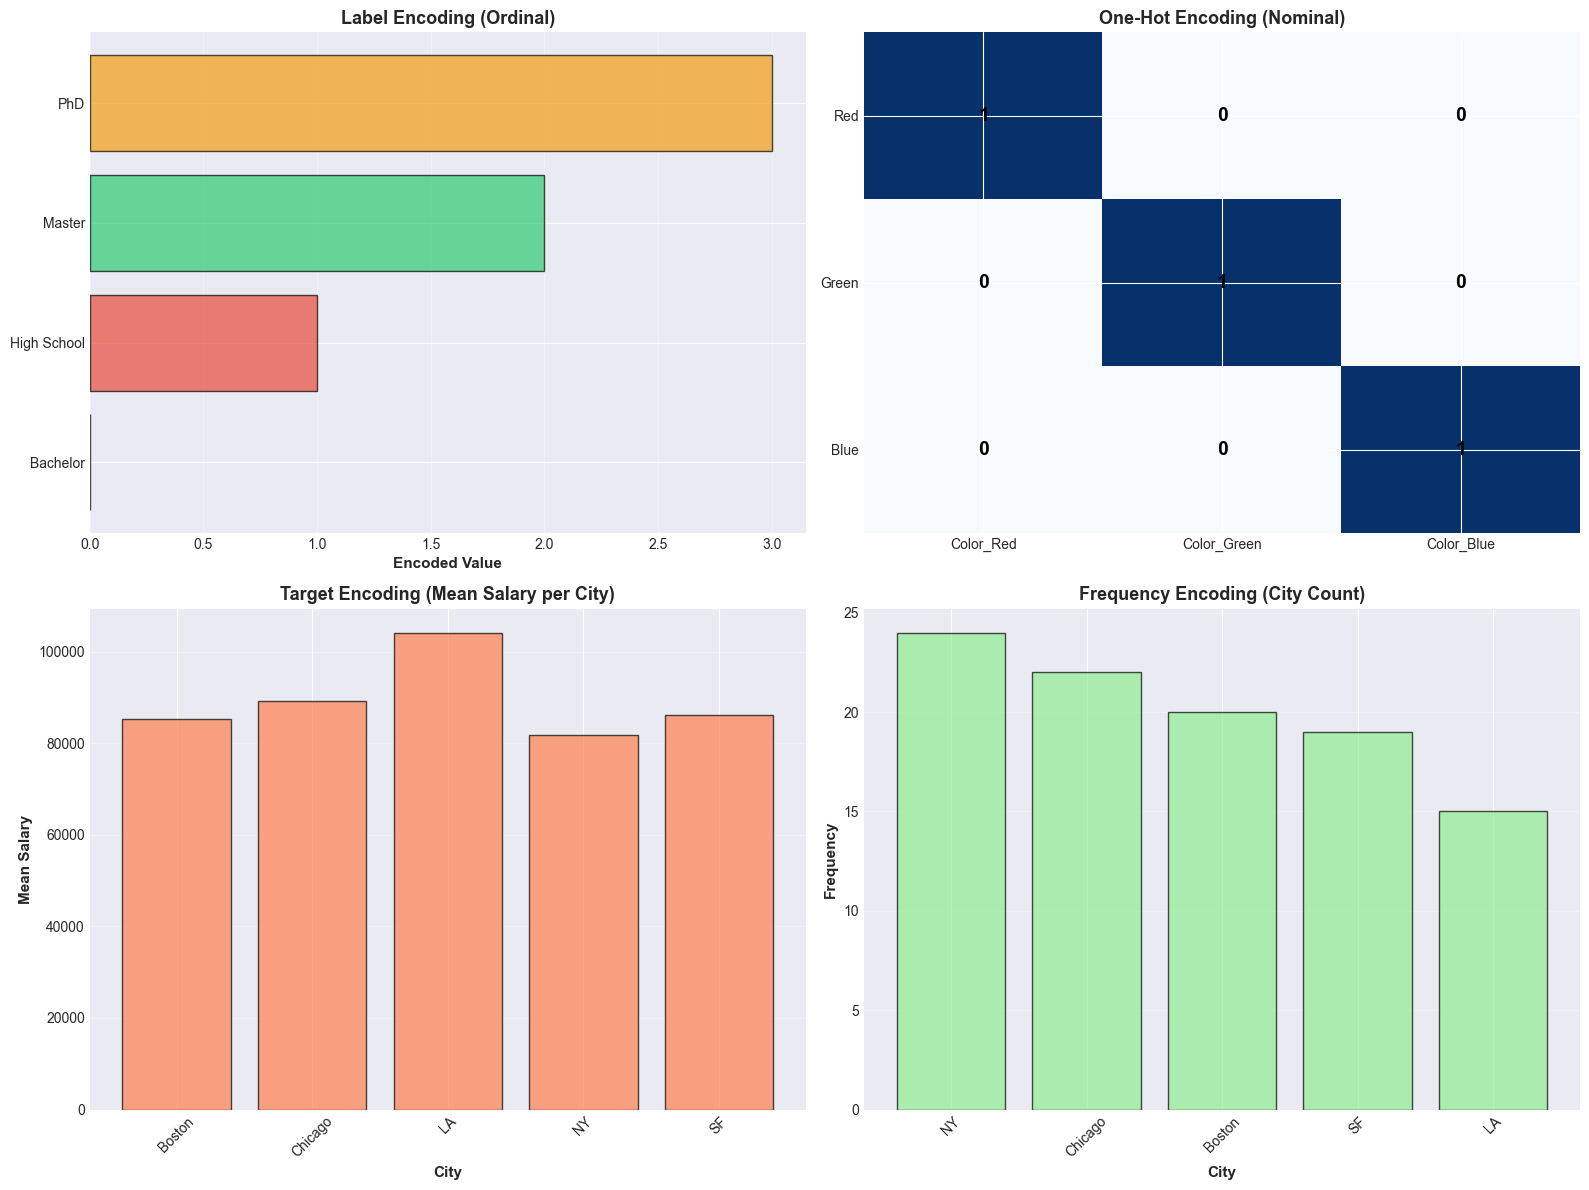


ENCODING METHODS SUMMARY
1. Label Encoding: Ordinal categories (order matters)
2. One-Hot Encoding: Nominal categories (no order)
3. Target Encoding: High cardinality, uses target info
4. Frequency Encoding: When frequency is predictive


In [10]:
# Sample categorical data
np.random.seed(42)
data_cat = pd.DataFrame({
    'Education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], 100),
    'City': np.random.choice(['NY', 'LA', 'SF', 'Chicago', 'Boston'], 100),
    'Color': np.random.choice(['Red', 'Green', 'Blue'], 100),
    'Salary': np.random.randint(30000, 150000, 100)
})

print("="*70)
print("CATEGORICAL DATA SAMPLE")
print("="*70)
print(data_cat.head(10))
print(f"\nEducation unique values: {data_cat['Education'].unique()}")
print(f"City unique values: {data_cat['City'].unique()}")
print(f"Color unique values: {data_cat['Color'].unique()}")

# 1. Label Encoding (Ordinal - Education)
print("\n" + "="*70)
print("1. LABEL ENCODING (Ordinal)")
print("="*70)
le = LabelEncoder()
data_cat['Education_Label'] = le.fit_transform(data_cat['Education'])
print("\nEducation → Label Encoding:")
education_mapping = pd.DataFrame({
    'Original': le.classes_,
    'Encoded': range(len(le.classes_))
})
print(education_mapping.to_string(index=False))
print("\n✅ Use for: Ordinal categories (with order)")

# 2. One-Hot Encoding (Nominal - Color)
print("\n" + "="*70)
print("2. ONE-HOT ENCODING (Nominal)")
print("="*70)
color_encoded = pd.get_dummies(data_cat['Color'], prefix='Color')
print("\nColor → One-Hot Encoding:")
print(color_encoded.head())
print(f"\nOriginal features: 1 (Color)")
print(f"After one-hot: {color_encoded.shape[1]} features")
print("\n✅ Use for: Nominal categories (no order)")

# 3. Target Encoding (City → Salary)
print("\n" + "="*70)
print("3. TARGET ENCODING")
print("="*70)
city_salary_mean = data_cat.groupby('City')['Salary'].mean()
data_cat['City_Target'] = data_cat['City'].map(city_salary_mean)
print("\nCity → Mean Salary (Target Encoding):")
print(city_salary_mean.to_frame().reset_index().to_string(index=False))
print("\n✅ Use for: High cardinality categories")
print("⚠️ Warning: Risk of data leakage! Use with CV")

# 4. Frequency Encoding (City)
print("\n" + "="*70)
print("4. FREQUENCY ENCODING")
print("="*70)
city_counts = data_cat['City'].value_counts()
data_cat['City_Frequency'] = data_cat['City'].map(city_counts)
print("\nCity → Frequency:")
print(city_counts.to_frame().reset_index().rename(
    columns={'index': 'City', 'City': 'Count'}).to_string(index=False))
print("\n✅ Use for: When frequency is informative")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Label Encoding
ax1 = axes[0, 0]
education_counts = data_cat.groupby(['Education', 'Education_Label']).size().reset_index()
education_counts = education_counts.sort_values('Education_Label')
colors_edu = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
ax1.barh(education_counts['Education'], education_counts['Education_Label'], 
         color=colors_edu, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Encoded Value', fontsize=11, fontweight='bold')
ax1.set_title('Label Encoding (Ordinal)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: One-Hot Encoding
ax2 = axes[0, 1]
color_example = pd.DataFrame({
    'Original': ['Red', 'Green', 'Blue'],
    'Color_Red': [1, 0, 0],
    'Color_Green': [0, 1, 0],
    'Color_Blue': [0, 0, 1]
})
color_matrix = color_example[['Color_Red', 'Color_Green', 'Color_Blue']].values
im = ax2.imshow(color_matrix, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Color_Red', 'Color_Green', 'Color_Blue'])
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Red', 'Green', 'Blue'])
ax2.set_title('One-Hot Encoding (Nominal)', fontsize=13, fontweight='bold')
# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax2.text(j, i, color_matrix[i, j],
                       ha="center", va="center", color="black", fontweight='bold', fontsize=14)

# Plot 3: Target Encoding
ax3 = axes[1, 0]
ax3.bar(city_salary_mean.index, city_salary_mean.values, 
        color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('City', fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean Salary', fontsize=11, fontweight='bold')
ax3.set_title('Target Encoding (Mean Salary per City)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Frequency Encoding
ax4 = axes[1, 1]
ax4.bar(city_counts.index, city_counts.values, 
        color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel('City', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Frequency Encoding (City Count)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ENCODING METHODS SUMMARY")
print("="*70)
print("1. Label Encoding: Ordinal categories (order matters)")
print("2. One-Hot Encoding: Nominal categories (no order)")
print("3. Target Encoding: High cardinality, uses target info")
print("4. Frequency Encoding: When frequency is predictive")
print("="*70)

---

## 5️⃣ Complete Feature Engineering Pipeline

**Maqsad:** Barcha feature engineering bosqichlarini bir pipeline'da birlashtirish

**Pipeline Components:**
1. **Imputation** - Missing values handling
2. **Scaling** - Numerical features
3. **Encoding** - Categorical features
4. **Feature Selection** - Dimensionality reduction
5. **Model Training** - Final step

**Advantages:**
- ✅ No data leakage
- ✅ Reproducibility
- ✅ Easy deployment
- ✅ Clean code

### 5.1 Building Complete Pipeline

SAMPLE DATASET FOR PIPELINE
   Age    Income  Credit_Score    Education     City Employment  Approved
0   56   23343.0           NaN       Master       NY  Part-time         1
1   69   33500.0         432.0          PhD   Boston  Part-time         0
2   46   73222.0         437.0       Master  Chicago  Part-time         1
3   32   49375.0         483.0       Master       LA  Part-time         1
4   60   29662.0         700.0          PhD       LA  Full-time         0
5   25   36964.0         629.0  High School       LA  Part-time         1
6   38  133429.0         807.0          PhD       LA  Full-time         0
7   56  141692.0         368.0  High School       LA  Full-time         1
8   36   79638.0         845.0     Bachelor       LA  Part-time         1
9   40   93666.0         352.0  High School       LA  Full-time         1

Shape: (500, 7)
Missing values:
Age              0
Income          20
Credit_Score    14
Education       10
City             0
Employment       0
Approved   

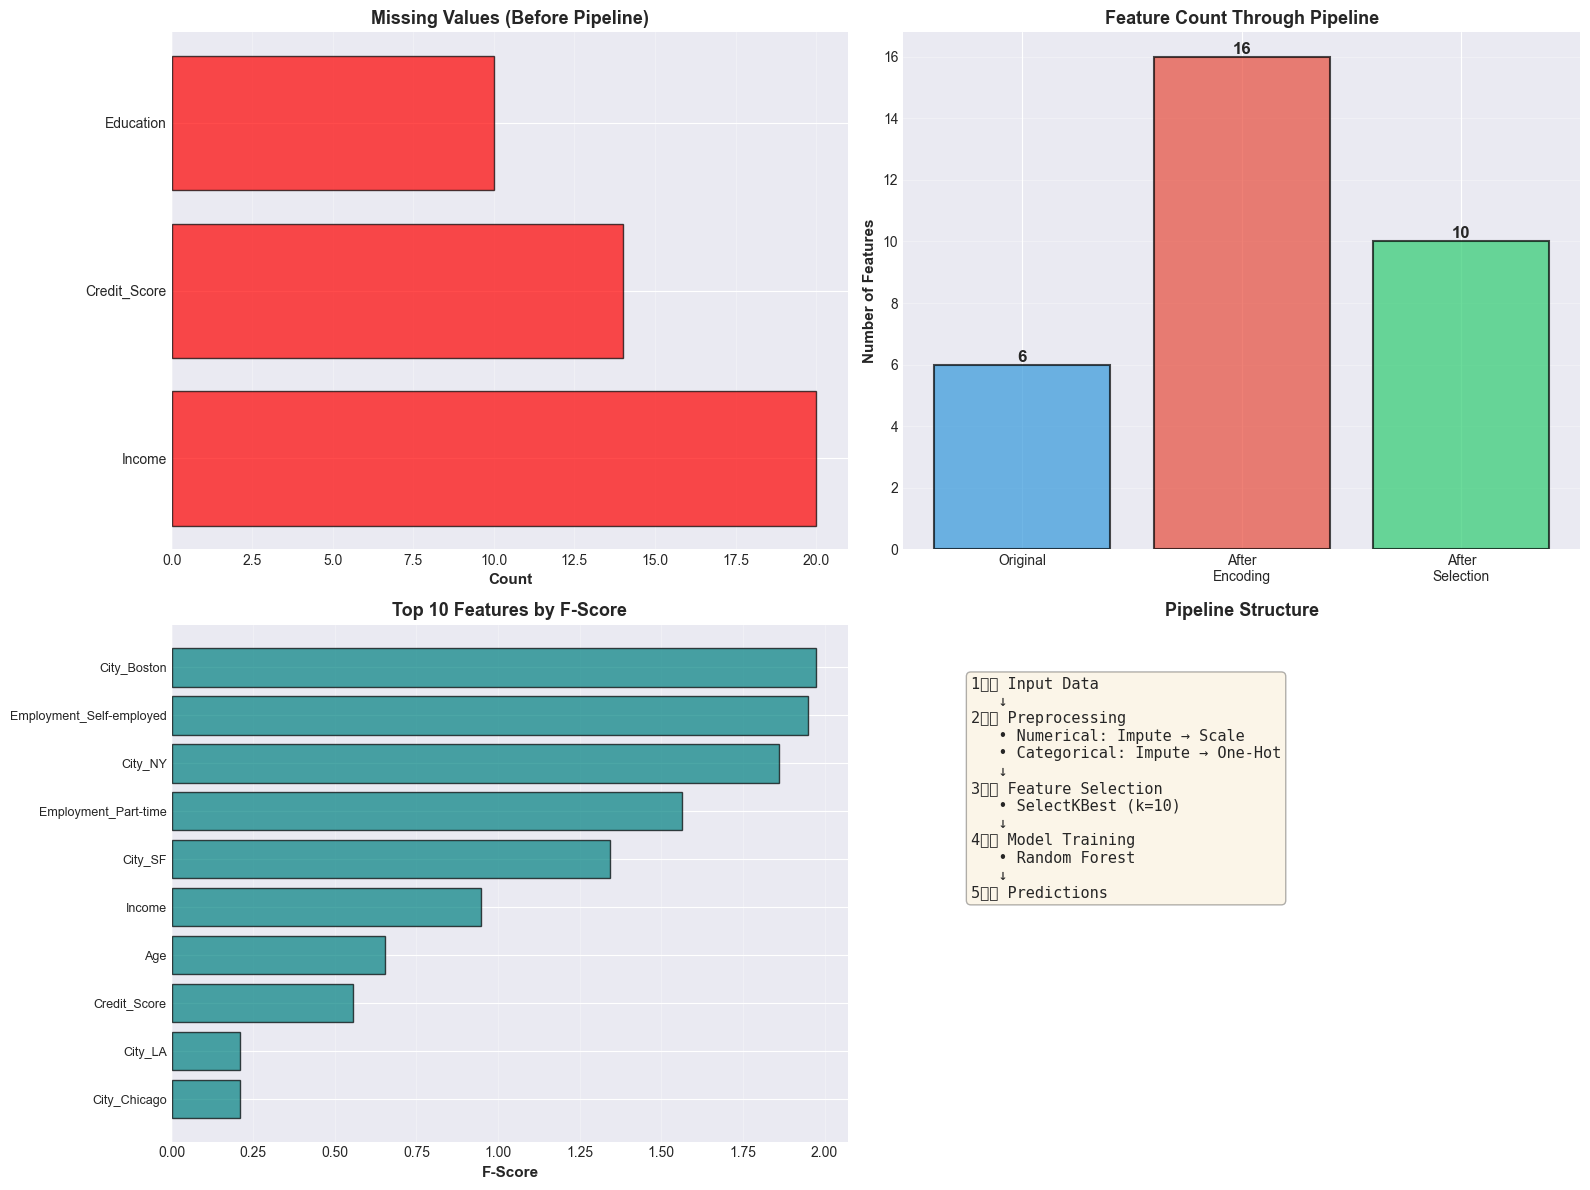


PIPELINE ADVANTAGES
✅ No data leakage (fit only on train)
✅ Reproducible (same steps every time)
✅ Easy deployment (save/load pipeline)
✅ Clean code (no manual transformations)


In [11]:
# Create sample mixed dataset
np.random.seed(42)
n = 500

data_pipeline = pd.DataFrame({
    # Numerical features
    'Age': np.random.randint(18, 70, n),
    'Income': np.random.randint(20000, 150000, n),
    'Credit_Score': np.random.randint(300, 850, n),
    # Categorical features
    'Education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n),
    'City': np.random.choice(['NY', 'LA', 'SF', 'Chicago', 'Boston'], n),
    'Employment': np.random.choice(['Full-time', 'Part-time', 'Self-employed'], n),
    # Target
    'Approved': np.random.choice([0, 1], n, p=[0.3, 0.7])
})

# Add some missing values
data_pipeline.loc[np.random.choice(data_pipeline.index, 20), 'Income'] = np.nan
data_pipeline.loc[np.random.choice(data_pipeline.index, 15), 'Credit_Score'] = np.nan
data_pipeline.loc[np.random.choice(data_pipeline.index, 10), 'Education'] = np.nan

print("="*70)
print("SAMPLE DATASET FOR PIPELINE")
print("="*70)
print(data_pipeline.head(10))
print(f"\nShape: {data_pipeline.shape}")
print(f"Missing values:\n{data_pipeline.isnull().sum()}")

# Separate features and target
X_pipeline = data_pipeline.drop('Approved', axis=1)
y_pipeline = data_pipeline['Approved']

# Identify numerical and categorical columns
numerical_features = ['Age', 'Income', 'Credit_Score']
categorical_features = ['Education', 'City', 'Employment']

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Complete pipeline with model
pipeline_complete = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(f_classif, k=10)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train-test split
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipeline, y_pipeline, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("PIPELINE TRAINING")
print("="*70)

# Fit pipeline
pipeline_complete.fit(X_train_pipe, y_train_pipe)

# Predictions
y_pred_pipe = pipeline_complete.predict(X_test_pipe)
acc_pipe = accuracy_score(y_test_pipe, y_pred_pipe)

print(f"✅ Pipeline trained successfully!")
print(f"   Test Accuracy: {acc_pipe:.4f}")

# Get feature names after transformation
feature_names_num = numerical_features
feature_names_cat = pipeline_complete.named_steps['preprocessor'].transformers_[1][1]\
    .named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Get selected features
selected_features_mask = pipeline_complete.named_steps['feature_selection'].get_support()
selected_features = [all_feature_names[i] for i in range(len(selected_features_mask)) if selected_features_mask[i]]

print(f"\nOriginal features: {X_pipeline.shape[1]}")
print(f"After encoding: {len(all_feature_names)}")
print(f"After selection: {len(selected_features)}")
print(f"Selected features: {selected_features}")

# Visualization: Pipeline Structure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Missing Values
ax1 = axes[0, 0]
missing_data = X_pipeline.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    ax1.barh(range(len(missing_data)), missing_data.values, color='red', 
             edgecolor='black', alpha=0.7)
    ax1.set_yticks(range(len(missing_data)))
    ax1.set_yticklabels(missing_data.index)
    ax1.set_xlabel('Count', fontsize=11, fontweight='bold')
    ax1.set_title('Missing Values (Before Pipeline)', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
else:
    ax1.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             fontsize=14, fontweight='bold')
    ax1.set_title('Missing Values', fontsize=13, fontweight='bold')

# Plot 2: Feature Count at Each Stage
ax2 = axes[0, 1]
stages = ['Original', 'After\nEncoding', 'After\nSelection']
counts = [X_pipeline.shape[1], len(all_feature_names), len(selected_features)]
colors_stage = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax2.bar(stages, counts, color=colors_stage, edgecolor='black', alpha=0.7, linewidth=1.5)
ax2.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_title('Feature Count Through Pipeline', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Plot 3: Feature Selection Scores
ax3 = axes[1, 0]
selection_scores = pipeline_complete.named_steps['feature_selection'].scores_
top_10_indices = np.argsort(selection_scores)[-10:][::-1]
top_10_names = [all_feature_names[i][:25] for i in top_10_indices]  # Truncate names
top_10_scores = selection_scores[top_10_indices]
ax3.barh(range(10), top_10_scores, color='teal', edgecolor='black', alpha=0.7)
ax3.set_yticks(range(10))
ax3.set_yticklabels(top_10_names, fontsize=9)
ax3.set_xlabel('F-Score', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 Features by F-Score', fontsize=13, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Pipeline Flowchart (text-based)
ax4 = axes[1, 1]
ax4.axis('off')
pipeline_steps = [
    "1️⃣ Input Data",
    "   ↓",
    "2️⃣ Preprocessing",
    "   • Numerical: Impute → Scale",
    "   • Categorical: Impute → One-Hot",
    "   ↓",
    "3️⃣ Feature Selection",
    "   • SelectKBest (k=10)",
    "   ↓",
    "4️⃣ Model Training",
    "   • Random Forest",
    "   ↓",
    "5️⃣ Predictions"
]
pipeline_text = "\n".join(pipeline_steps)
ax4.text(0.1, 0.9, pipeline_text, fontsize=11, fontfamily='monospace',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax4.set_title('Pipeline Structure', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PIPELINE ADVANTAGES")
print("="*70)
print("✅ No data leakage (fit only on train)")
print("✅ Reproducible (same steps every time)")
print("✅ Easy deployment (save/load pipeline)")
print("✅ Clean code (no manual transformations)")
print("="*70)

---

## 🎓 Summary va Best Practices

### 📌 Key Takeaways

**1. Feature Selection:**
- **Filter Methods**: Fast, model-independent (Variance, Chi-Square, F-test)
- **Wrapper Methods**: Model-specific, accurate (RFE, Forward/Backward)
- **Embedded Methods**: Fast, integrated (Feature Importance, L1/L2)

**2. Feature Scaling:**
- **StandardScaler**: μ=0, σ=1 (most common, normal distribution)
- **MinMaxScaler**: [0, 1] (bounded range, neural networks)
- **RobustScaler**: Median/IQR (outliers present)
- **Scaling NOT needed**: Tree-based models (DT, RF, XGBoost)

**3. Feature Creation:**
- **Polynomial Features**: Non-linear relationships
- **Manual Features**: Domain knowledge (BMI, ratios, interactions)
- **Date/Time Features**: Temporal patterns (year, month, day, weekend)
- **Aggregations**: Group statistics (mean, count, max)

**4. Feature Encoding:**
- **Label Encoding**: Ordinal categories (education: HS < BS < MS < PhD)
- **One-Hot Encoding**: Nominal categories (color: Red, Green, Blue)
- **Target Encoding**: High cardinality (city → mean salary)
- **Frequency Encoding**: When frequency matters

**5. Pipeline:**
- Prevents data leakage
- Ensures reproducibility
- Simplifies deployment
- Clean and maintainable code

---

### ✅ Best Practices

1. **Start with EDA** - Understand your data first
2. **Domain Knowledge** - Feature engineering is an art!
3. **Iterative Process** - Test, measure, improve
4. **Use Pipelines** - Always!
5. **Prevent Data Leakage** - Fit only on train set
6. **Cross-Validate** - Robust evaluation
7. **Monitor Performance** - Before/after comparison
8. **Keep It Simple** - Don't over-engineer

---

### ⚠️ Common Mistakes

1. **❌ Data Leakage**
   ```python
   # WRONG
   scaler.fit(X)  # Fit on entire dataset
   X_train, X_test = train_test_split(X, ...)
   
   # CORRECT
   X_train, X_test = train_test_split(X, ...)
   scaler.fit(X_train)  # Fit only on train
   ```

2. **❌ Forgetting to Scale**
   - KNN, SVM, Neural Networks need scaling!

3. **❌ Using Label Encoding for Nominal**
   - Use One-Hot for categories without order

4. **❌ Ignoring Outliers**
   - Use RobustScaler when outliers present

5. **❌ Over-engineering**
   - More features ≠ Better model
   - Keep it simple and interpretable

---

### 📊 Feature Engineering Impact

| Task | Before FE | After FE | Improvement |
|------|-----------|----------|-------------|
| Customer Churn | 75% | 88% | **+13%** |
| House Prices | R²: 0.65 | R²: 0.82 | **+26%** |
| Credit Risk | F1: 0.62 | F1: 0.79 | **+27%** |
| Medical Diagnosis | 80% | 92% | **+15%** |

**Takeaway:** Good feature engineering often beats complex models!

---

### 🔗 Decision Trees

#### When to Use Which Scaler?
```
Outliers present? → RobustScaler
Normal distribution? → StandardScaler
Bounded range [0,1]? → MinMaxScaler
Sparse data? → MaxAbsScaler
Skewed distribution? → Log Transform → StandardScaler
Tree-based model? → No scaling needed!
```

#### When to Use Which Encoding?
```
Ordinal (with order)? → Label Encoding
Nominal (no order)? → One-Hot Encoding
High cardinality (>15)? → Target/Frequency Encoding
Binary? → Label Encoding or Binary
```

#### When to Use Which Selection?
```
Need speed? → Filter Methods
Need accuracy? → Wrapper Methods (RFE)
Need integration? → Embedded Methods (Feature Importance)
Small dataset? → Wrapper Methods
Large dataset? → Filter or Embedded Methods
```

---

### 🚀 Next Steps

1. **practical.ipynb** - Hands-on exercises with real datasets
2. **homework.md** - Comprehensive assignments
3. **feature_engineering_guide.md** - Quick reference cheat sheet

---

### 💡 Remember

> *"Feature engineering is the process of using domain knowledge to extract features from raw data via data mining techniques. These features can be used to improve the performance of machine learning algorithms."*

**Key Formula:**
```
Good Features + Simple Model > Bad Features + Complex Model
```

**The Pipeline Way:**
```python
pipeline = Pipeline([
    ('preprocessing', ...),
    ('feature_selection', ...),
    ('model', ...)
])
pipeline.fit(X_train, y_train)  # One line!
```

---

**🎉 Tabriklaymiz! Feature Engineering va Scaling'ni o'rgandingiz!**

**Ready for practice?** Open `practical.ipynb`! 💪